In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
new_df=pd.read_csv("questions.csv")

In [5]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [6]:
new_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 404351 entries, 0 to 404350
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            404351 non-null  int64
 1   qid1          404351 non-null  int64
 2   qid2          404351 non-null  int64
 3   question1     404350 non-null  str  
 4   question2     404349 non-null  str  
 5   is_duplicate  404351 non-null  int64
dtypes: int64(4), str(2)
memory usage: 18.5 MB


In [7]:
new_df.sample(10)

,id,qid1,qid2,question1,question2,is_duplicate
322235,322235,632139,632140,What is something every teenager should do bef...,What things should teenagers know before going...,0
321398,321398,630519,630520,"If you live in Sweden, what Amazon site do you...","If you live in Switzerland, what Amazon site d...",0
182830,182830,361087,361088,Is a world war going to happen?,How soon is world war III?,1
202556,202556,399675,399676,Is it possible to fall in love within 2 days?,Is it possible to fall in love in just 2 months?,0
75919,75919,150854,150855,I am unable to tag people on Instagram. Why?,Some people seem to have unabled the 'tagged' ...,0
66471,66471,132155,132156,Do antibiotics weaken one's immune system? If ...,What is going on with my body and Illnesses?,0
399967,399967,781407,781408,How does King Digital Entertainment make money?,What is King Digital Entertainment? What do th...,0
374716,374716,733122,733123,What part-time jobs can an MBA student do in B...,Where could I get a part time job in Bangalore?,0
196641,196641,388107,388108,What is the effect of running a 32 bit program...,Can a 64-bit computer run 32-bit software?,0
40646,40646,80962,80963,How can I make a vr game?,How do I make a vr game?,1


In [8]:
new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [9]:
new_df.dropna(inplace=True)

In [10]:
new_df.duplicated().sum()

np.int64(0)

In [11]:
print(new_df['is_duplicate'].value_counts())
print(100*new_df['is_duplicate'].value_counts()/new_df['is_duplicate'].count())

is_duplicate
0    255042
1    149306
Name: count, dtype: int64
is_duplicate
0    63.074876
1    36.925124
Name: count, dtype: float64


In [12]:
## As we can see it the clear,imbalanced dataset

In [13]:
# identification of repeated questions:
qid=pd.Series(new_df['qid1'].tolist()+new_df['qid2'].tolist())
print("Number of unique questions ",np.unique(qid).shape[0])
x=qid.value_counts()>1
print("number of questions getting reapeted",x[x].shape[0])

Number of unique questions  789795
number of questions getting reapeted 13698


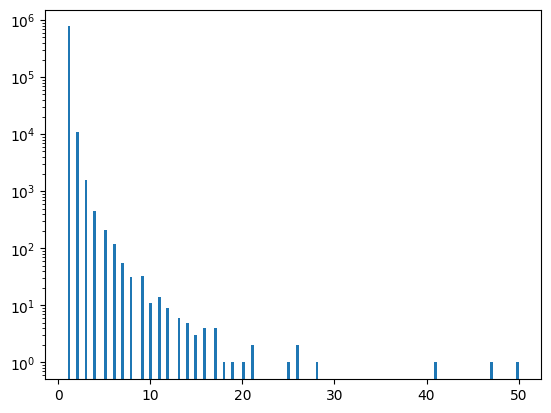

In [14]:
# Frequnecy of repeated questions histogram
plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')
plt.show()

## Just apply bow and apply randomforest and check the accuracy,it is the basic step

In [15]:
# bag of words
q1 = list(new_df['question1'])
q2 = list(new_df['question2'])
from sklearn.feature_extraction.text import CountVectorizer
cv1 = CountVectorizer(max_features=3000)
cv1.fit(q1+q2)
q1_arr = cv1.transform(q1)   # sparse
q2_arr = cv1.transform(q2)   # sparse
# X = hstack([q1_arr, q2_arr])

In [16]:
q1_arr

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3511786 stored elements and shape (404348, 3000)>

In [17]:
# import pandas as pd
from scipy.sparse import hstack
df = hstack([q1_arr, q2_arr])
y = new_df['is_duplicate']

# df = pd.DataFrame(X)
# df['target'] = y.values

In [18]:
# df.head()


In [19]:
#apply random_forest

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
x_train,x_test,y_train,y_test=train_test_split(df,y,test_size=0.2,random_state=42)
rf=SGDClassifier()
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)
print(accuracy_score(y_test,y_pred))
confusion_matrix(y_test,y_pred)

0.7366390503276864


array([[46015,  5225],
       [16073, 13557]])

In [21]:

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
rf=XGBClassifier()
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)
print(accuracy_score(y_test,y_pred))
confusion_matrix(y_test,y_pred)

0.7500061827624582


array([[46609,  4631],
       [15586, 14044]])

In [22]:
## We need to get improvement ,as we have not done any of steps for improvemnet

In [23]:
# by Manual feature engineering,created extra 7 features 

In [24]:
def common_words(row):
    w1=set(map(lambda word:word.lower().strip(),row['question1'].split(" ")))
    w2=set(map(lambda word:word.lower().strip(),row['question2'].split(" ")))
    return len(w1 & w2)

In [25]:
def total_words(row):
    w1=set(map(lambda word:word.lower().strip(),row['question1'].split(" ")))
    w2=set(map(lambda word:word.lower().strip(),row['question2'].split(" ")))
    return (len(w1)+len(w2))

In [26]:
new_df['q1_len']=new_df['question1'].str.len()
new_df['q2_len']=new_df['question2'].str.len()
new_df['q1_num_words']=new_df['question1'].apply(lambda row: len(row.split(" ")))
new_df['q2_num_words']=new_df['question2'].apply(lambda row: len(row.split(" ")))
new_df['word_common']=new_df.apply(common_words,axis=1)
new_df['total_words']=new_df.apply(total_words,axis=1)
new_df['word_share']=round(new_df['word_common']/new_df['total_words'],2)

C:\Users\nihal\AppData\Local\Temp\ipykernel_15612\664463467.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_common'],label='non duplicate')
C:\Users\nihal\AppData\Local\Temp\ipykernel_15612\664463467.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplo

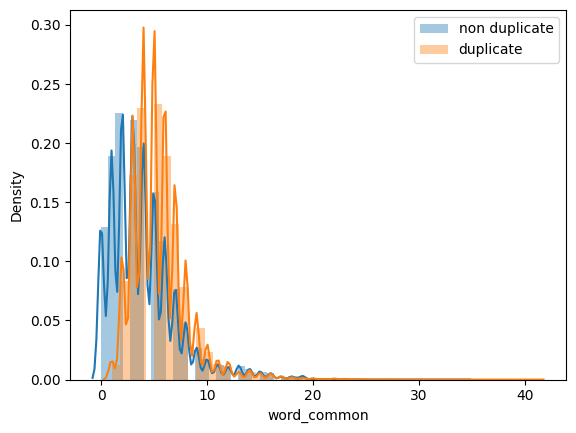

In [27]:
# analyze features
import seaborn as sns 
# common words
sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_common'],label='non duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]['word_common'],label='duplicate')
plt.legend()
plt.show()

In [28]:
# if word_common >4 its prob of duplicate is more as word common <=4 the prob is less

C:\Users\nihal\AppData\Local\Temp\ipykernel_15612\1446561759.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df[new_df['is_duplicate'] == 0]['total_words'],label='non duplicate')
C:\Users\nihal\AppData\Local\Temp\ipykernel_15612\1446561759.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distp

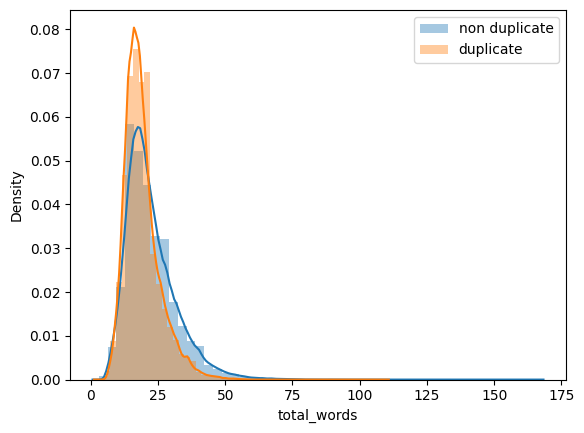

In [29]:
# total words
sns.distplot(new_df[new_df['is_duplicate'] == 0]['total_words'],label='non duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]['total_words'],label='duplicate')
plt.legend()
plt.show()

In [30]:
# if total_words<40 the chance of getting duplicated is more comparatively >40

C:\Users\nihal\AppData\Local\Temp\ipykernel_15612\3920354522.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['q1_len'])


min char 1
max char 623
avg num of  char 59.53388665209176


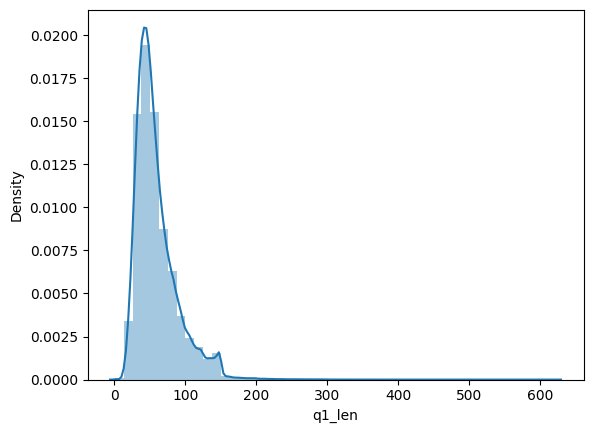

In [31]:

sns.distplot(new_df['q1_len'])
print("min char",new_df['q1_len'].min())
print("max char",new_df['q1_len'].max())
print("avg num of  char",new_df['q1_len'].mean())

C:\Users\nihal\AppData\Local\Temp\ipykernel_15612\2643724033.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['q2_len'])


min char 1
max char 1169
avg num of  char 60.10302511697844


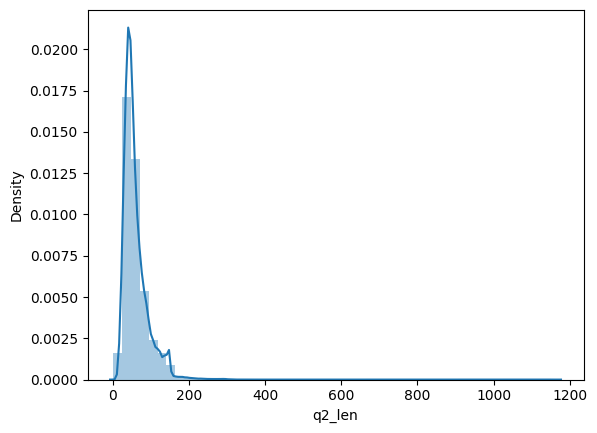

In [32]:
sns.distplot(new_df['q2_len'])
print("min char",new_df['q2_len'].min())
print("max char",new_df['q2_len'].max())
print("avg num of  char",new_df['q2_len'].mean())

C:\Users\nihal\AppData\Local\Temp\ipykernel_15612\2331991685.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['q1_num_words'])


min char 1
max char 125
avg num of  char 10.944208948727335


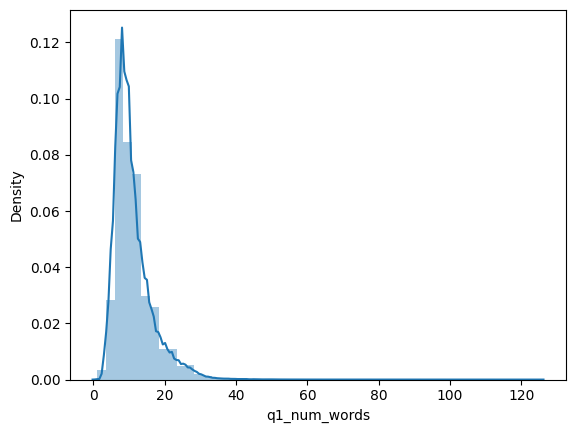

In [33]:
sns.distplot(new_df['q1_num_words'])
print("min char",new_df['q1_num_words'].min())
print("max char",new_df['q1_num_words'].max())
print("avg num of  char",new_df['q1_num_words'].mean())

C:\Users\nihal\AppData\Local\Temp\ipykernel_15612\3435506980.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['q2_num_words'])


min char 1
max char 237
avg num of  char 11.184279383105642


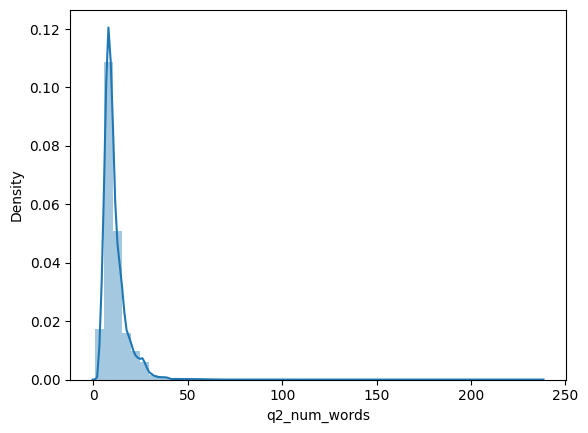

In [34]:
sns.distplot(new_df['q2_num_words'])
print("min char",new_df['q2_num_words'].min())
print("max char",new_df['q2_num_words'].max())
print("avg num of  char",new_df['q2_num_words'].mean())

C:\Users\nihal\AppData\Local\Temp\ipykernel_15612\542246512.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_share'],label='non duplicate')
C:\Users\nihal\AppData\Local\Temp\ipykernel_15612\542246512.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot

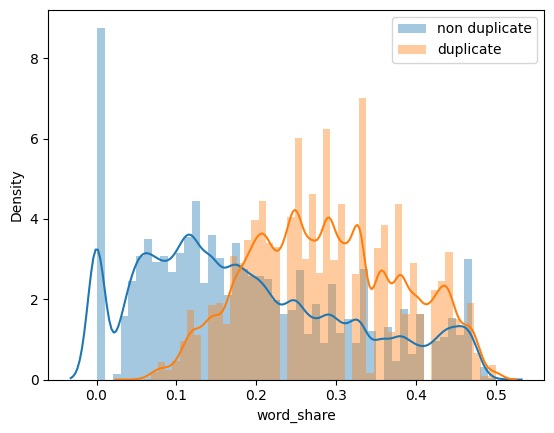

In [35]:
# word share
sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_share'],label='non duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]['word_share'],label='duplicate')
plt.legend()
plt.show()

In [36]:
# word_share<0.2 it has less prob of getting duplicated

In [37]:
# creating new df with 7(from feature eng)+2(q1 and q2)+1(o/p) columns ,total independent columns are=9 and total dependent columns=1

In [38]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,total_words,word_share
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0,66,57,14,12,10,23,0.43
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0,51,88,8,13,4,20,0.20
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0,73,59,14,10,4,24,0.17
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0,50,65,11,9,0,19,0.00
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0,76,39,13,7,2,20,0.10


In [39]:
new_df.drop(columns=['id','qid1','qid2','question1','question2'],inplace=True)

In [40]:
from scipy.sparse import csr_matrix
z=csr_matrix(new_df)
X=hstack([df,z])

In [41]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df,y,test_size=0.2,random_state=1)

In [42]:
rf = SGDClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.7350686286632867

In [43]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.746679856559911

In [44]:
# do preprocessing + advance feature engineering you should do to get more accurate prediction.